# Sony Bravia TV Reviews — NLP Project

**Objective:** Build a model that can analyze and classify product reviews using Natural Language Processing (NLP) and Neural Networks.

**Dataset:** `SonyBravia_TV_Reviews.csv` — ~5,000 Sony Bravia TV product reviews.

**Classification Task:** 3-class sentiment classification
- `0` → **Negative** (1-2 stars equivalent)
- `1` → **Neutral**  (3 stars equivalent)
- `2` → **Positive** (4-5 stars equivalent)

## Section 0: Setup & Imports

Import all necessary libraries for data processing, visualisation, NLP, and neural network construction.

In [1]:
pip install pandas numpy lime matplotlib seaborn nltk tensorflow gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard libraries
import os
import re
import string
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('punkt',        quiet=True)
nltk.download('omw-1.4',      quiet=True)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Scikit-learn metrics & SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE

# Reproducibility seed
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Global hyper-parameters
MAX_WORDS   = 10000   # vocabulary size
MAX_LEN     = 60      # max sequence length (tokens)
EMBED_DIM   = 100     # GloVe embedding dimension
BATCH_SIZE  = 64
NUM_CLASSES = 3       # Negative / Neutral / Positive

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")
print("✅ All libraries loaded successfully!")

2026-03-11 22:55:25.721552: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.16.2
Keras version      : 3.13.2
NumPy version      : 1.26.4
Pandas version     : 3.0.0
✅ All libraries loaded successfully!


## Section 1: Data Loading & Exploratory Data Analysis (EDA)

Understanding the structure of the dataset before building any model.

**Key EDA steps:**
1. Load the CSV and inspect shape, dtypes, and missing values
2. Review-length distribution
3. Word-frequency analysis (top-40 most common words)
4. Class distribution (after labeling is done in Section 3)

In [3]:
# 1.1  Load the raw CSV
df_raw = pd.read_csv('SonyBravia_TV_Reviews.csv')

print("Shape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nData types:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isnull().sum())
df_raw.head(10)


Shape: (6722, 2)

Column names: ['Product Name', 'Review Text']

Data types:
 Product Name    str
Review Text     str
dtype: object

Missing values:
 Product Name    0
Review Text     0
dtype: int64


,Product Name,Review Text
0,Sony Bravia 55 inch 4K Smart TV,Amazon - The TV's display brightness is perfec...
1,Sony Bravia 55 inch 4K Smart TV,"The TV's stand is stable and well-built. Also,..."
2,Sony Bravia 55 inch 4K Smart TV,Color calibration out of the box is almost per...
3,Sony Bravia 55 inch 4K Smart TV,Amazon - Color reproduction is very accurate. ...
4,Sony Bravia 55 inch 4K Smart TV,The TV's picture adjustments allow very fine-t...
5,Sony Bravia 55 inch 4K Smart TV,4K videos on YouTube play without any stutteri...
6,Sony Bravia 55 inch 4K Smart TV,Audio quality while playing music videos is ri...
7,Sony Bravia 55 inch 4K Smart TV,Voice recognition via the remote works well ev...
8,Sony Bravia 55 inch 4K Smart TV,The audio is clear and sufficiently loud for a...
9,Sony Bravia 55 inch 4K Smart TV,Build quality is excellent. The TV feels durab...


In [4]:
# 1.2  Basic statistics on review text
df_raw['review_length'] = df_raw['Review Text'].astype(str).apply(lambda x: len(x.split()))
df_raw['char_length']   = df_raw['Review Text'].astype(str).apply(len)

print("Review word-count statistics:")
print(df_raw['review_length'].describe().round(2))
print("\nCharacter-count statistics:")
print(df_raw['char_length'].describe().round(2))


Review word-count statistics:
count    6722.00
mean       13.87
std         3.32
min         7.00
25%        12.00
50%        14.00
75%        16.00
max        34.00
Name: review_length, dtype: float64

Character-count statistics:
count    6722.00
mean       85.28
std        17.61
min        38.00
25%        76.00
50%        83.00
75%        93.00
max       180.00
Name: char_length, dtype: float64


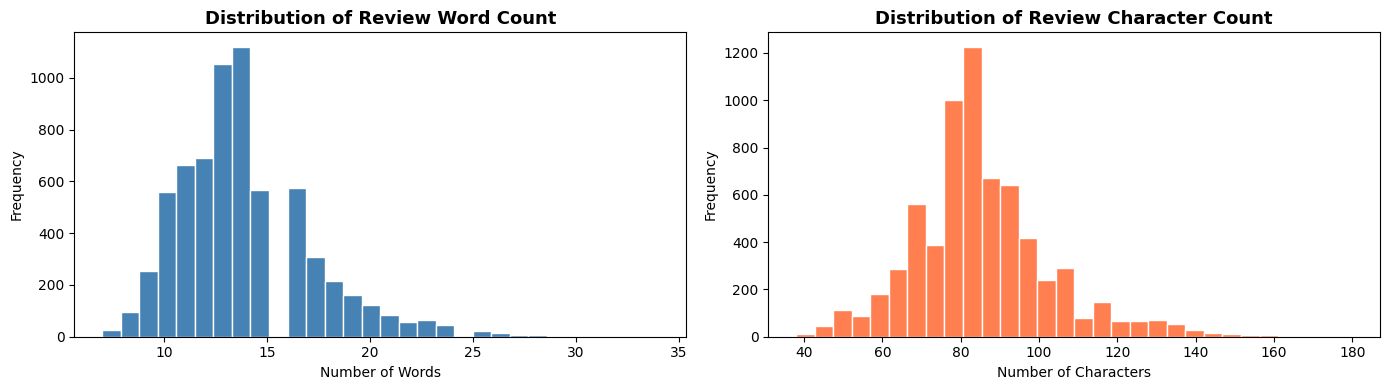

✅ Length distribution plots saved.


In [5]:
# 1.3  Review-length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['review_length'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Review Word Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_raw['char_length'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Review Character Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
# plt.savefig('eda_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Length distribution plots saved.")


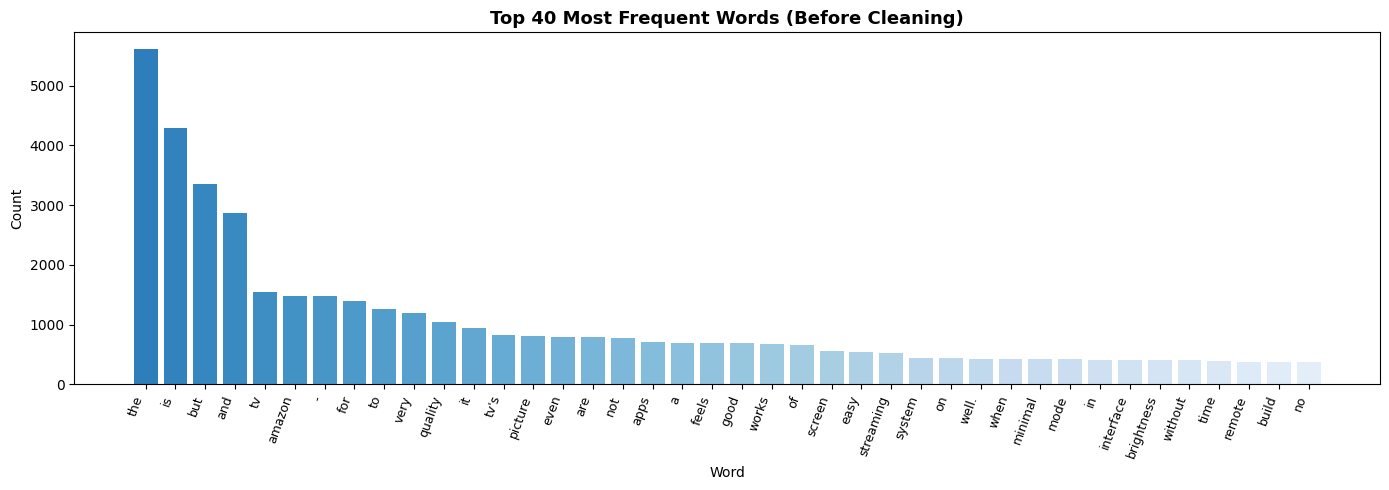

✅ Word frequency plot saved.


In [6]:
#1.4  Word-frequency analysis
all_words = ' '.join(df_raw['Review Text'].astype(str).tolist()).lower().split()
word_freq  = Counter(all_words).most_common(40)
words_  = [w[0] for w in word_freq]
counts_ = [w[1] for w in word_freq]

plt.figure(figsize=(14, 5))
bars = plt.bar(words_, counts_, color=plt.cm.Blues_r(np.linspace(0.3, 0.9, 40)))
plt.xticks(rotation=70, ha='right', fontsize=9)
plt.title('Top 40 Most Frequent Words (Before Cleaning)', fontsize=13, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Count')
plt.tight_layout()
# plt.savefig('eda_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word frequency plot saved.")


In [7]:
# 1.5  How many unique products are in the dataset?
print("Unique product names:", df_raw['Product Name'].nunique())
print(df_raw['Product Name'].value_counts())


Unique product names: 1
Product Name
Sony Bravia 55 inch 4K Smart TV    6722
Name: count, dtype: int64


## Section 2: Text Cleaning & Preprocessing

A clean text representation leads to better NLP performance.

**Steps performed:**
1. Remove `Amazon -` prefix (review source tag)
2. Lowercase all text
3. Remove HTML tags (regex)
4. Remove punctuation and special characters
5. Strip extra whitespace
6. Remove English stopwords (NLTK)
7. Lemmatize words (WordNetLemmatizer)

In [8]:
# 2.1  Define the cleaning pipeline
lemmatizer = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Full text-cleaning pipeline."""
    # (a) Remove 'Amazon -' source prefix
    text = re.sub(r'(?i)^Amazon\s*-\s*', '', text)

    # (b) Lowercase
    text = text.lower()

    # (c) Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # (d) Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # (e) Remove punctuation and special characters
    text = re.sub(r"[^a-z\s]", ' ', text)

    # (f) Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # (g) Tokenize and remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # (h) Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Apply cleaning
df_raw['clean_text'] = df_raw['Review Text'].astype(str).apply(clean_text)

print("Sample Before Cleaning:")
print(df_raw['Review Text'].iloc[0])
print("\nSample After Cleaning:")
print(df_raw['clean_text'].iloc[0])


Sample Before Cleaning:
Amazon - The TV's display brightness is perfect even in daylight. No issues with glare.

Sample After Cleaning:
display brightness perfect even daylight issue glare


In [9]:
# 2.2  Drop rows where cleaning resulted in empty text
df_raw = df_raw[df_raw['clean_text'].str.strip().str.len() > 0].copy()
df_raw.reset_index(drop=True, inplace=True)

print(f"Rows after cleaning: {len(df_raw)}")
assert len(df_raw) > 4000, "Too many rows dropped during cleaning!"

# Update review length after cleaning
df_raw['clean_length'] = df_raw['clean_text'].apply(lambda x: len(x.split()))
print("\nCleaned review word-count stats:")
print(df_raw['clean_length'].describe().round(2))


Rows after cleaning: 6722

Cleaned review word-count stats:
count    6722.00
mean        8.45
std         1.91
min         3.00
25%         7.00
50%         8.00
75%         9.00
max        17.00
Name: clean_length, dtype: float64


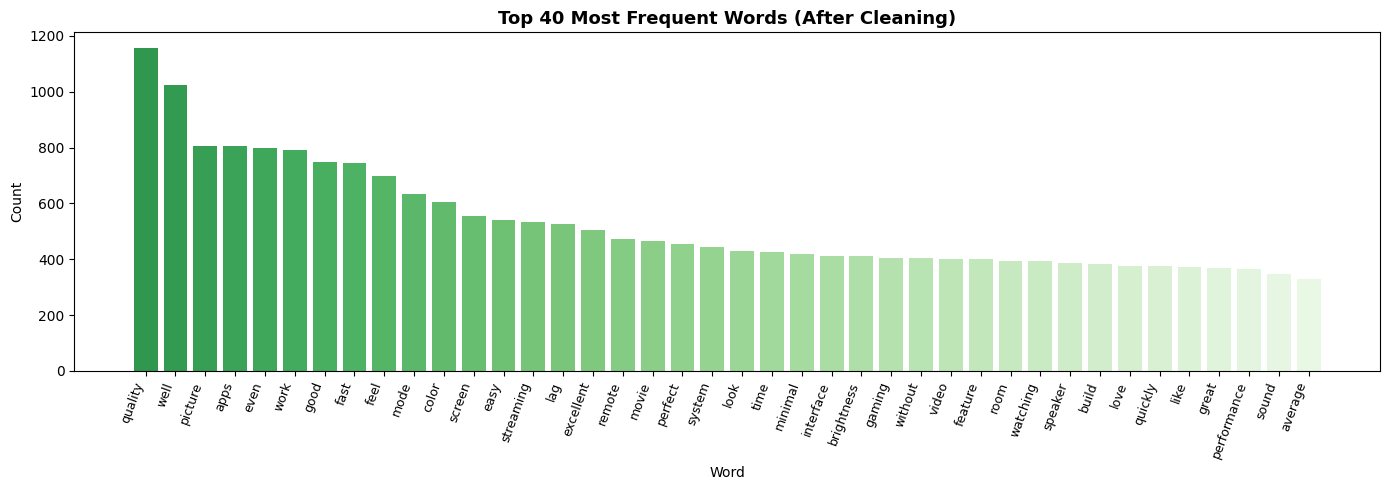

In [10]:
# 2.3  Word frequency AFTER cleaning
all_clean_words = ' '.join(df_raw['clean_text'].tolist()).split()
clean_freq      = Counter(all_clean_words).most_common(40)
cwords_  = [w[0] for w in clean_freq]
ccounts_ = [w[1] for w in clean_freq]

plt.figure(figsize=(14, 5))
plt.bar(cwords_, ccounts_, color=plt.cm.Greens_r(np.linspace(0.3, 0.9, 40)))
plt.xticks(rotation=70, ha='right', fontsize=9)
plt.title('Top 40 Most Frequent Words (After Cleaning)', fontsize=13, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Count')
plt.tight_layout()
# plt.savefig('eda_clean_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 3: Sentiment Labeling

we create a **custom 3-class label** using a lexicon-based keyword scorer.

**Scoring logic:**
- Each positive signal word adds `+1` to the score
- Each negative signal word adds `-1` to the score
- `score ≥ 2` → **Positive (2)**
- `score == 1` → **Positive (2)** (lean positive)
- `score == 0` → **Neutral (1)**
- `score < 0`  → **Negative (0)**

This matches the bonus idea: **Negative [1-2★], Neutral [3★], Positive [4-5★]**

In [11]:
# 3.1 Improved Rule-Based Sentiment Labeling
import re
from collections import Counter


# Sentiment lexicons
POSITIVE_WORDS = {
    'excellent':3,'perfect':3,'fantastic':3,'amazing':3,'great':2,
    'superb':3,'outstanding':3,'wonderful':3,'brilliant':3,
    'impressive':2,'stunning':3,'beautiful':2,'crisp':2,
    'rich':2,'smooth':2,'fast':2,'clear':2,'accurate':2,
    'intuitive':2,'seamless':3,'flawless':3,'responsive':2,
    'premium':2,'vibrant':2,'immersive':2,'comfortable':2,
    'easy':2,'love':3,'awesome':3,'durable':2,'stable':2,
    'enjoyable':2,'good':2,'bright':2,'sharp':2
}

NEGATIVE_WORDS = {
    'bad':2,'poor':2,'terrible':3,'awful':3,'slow':2,
    'lag':2,'laggy':2,'freeze':2,'freezes':2,'not':2,'worst':3,
    'crash':3,'crashes':3,'bug':2,'bugs':2,
    'weak':2,'dim':2,'dull':2,'blurry':2,'blur':2,
    'washed':2,'annoying':2,'frustrating':3,
    'expensive':2,'overpriced':3,
    'average':2,'limitations':2,'dissatisfied':3,
    'unusual':2,'lacks':2,'cheap':2,
}

NEUTRAL_WORDS = {
    "acceptable", "average", "but", "could", "decent", 
    "fairly", "however", "minor", "moderate", "occasionally", 
    "ok", "okay", "slightly", "somewhat", "sometimes", "though"
}

NEGATIONS = {"not","never","no","hardly","rarely"}

CONTRAST_WORDS = {"but","however","although","though","yet"}

# Helper
def clean_text(text):

    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+"," ",text)

    return text.strip()

# Sentence scoring
def score_sentence(sentence):

    words = sentence.split()
    counts = Counter(words)

    score = 0

    for word in counts:

        if word in POSITIVE_WORDS:
            score += POSITIVE_WORDS[word] * counts[word]

        if word in NEGATIVE_WORDS:
            score -= NEGATIVE_WORDS[word] * counts[word]

        if word in NEUTRAL_WORDS:
            score *= 0.7

    # negation logic
    for i,w in enumerate(words[:-1]):

        if w in NEGATIONS:

            nxt = words[i+1]

            if nxt in POSITIVE_WORDS:
                score -= POSITIVE_WORDS[nxt]

            if nxt in NEGATIVE_WORDS:
                score += NEGATIVE_WORDS[nxt]

    return score



def sentiment_score(review):

    review = clean_text(review)

    parts = re.split(r'\bbut\b|\bhowever\b|\balthough\b|\bthough\b|\byet\b',review)

    total = 0

    for i,s in enumerate(parts):

        sc = score_sentence(s)

        # stronger weight for final clause
        weight = 1.5 if i == len(parts)-1 else 1

        total += sc * weight

    return total


def score_to_label(score):

    if score >= 2:
        return 2   # Positive

    elif score <= -2:
        return 0   # Negative

    else:
        return 1   # Neutral


scores = df_raw["Review Text"].apply(sentiment_score)

df_raw["label"] = scores.apply(score_to_label)

print("Labeling complete")
print(df_raw["label"].value_counts())

Labeling complete
label
2    3834
1    1874
0    1014
Name: count, dtype: int64


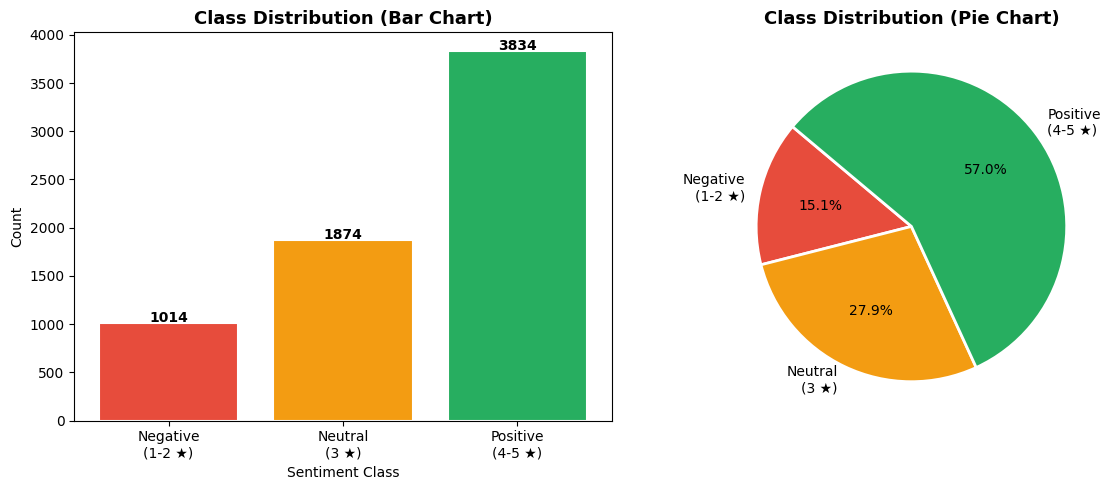

✅ Class distribution plot saved.


In [12]:
# 3.2  Visualise class distribution
label_names = {0: 'Negative\n(1-2 ★)', 1: 'Neutral\n(3 ★)', 2: 'Positive\n(4-5 ★)'}
counts = df_raw['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar([label_names[i] for i in counts.index], counts.values,
            color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values,
            labels=[label_names[i] for i in counts.index],
            autopct='%1.1f%%', startangle=140,
            colors=['#e74c3c', '#f39c12', '#27ae60'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
# plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class distribution plot saved.")


In [13]:
# 3.3  Show sample reviews per class
print("=" * 70)
for lbl, name in [(0, 'NEGATIVE'), (1, 'NEUTRAL'), (2, 'POSITIVE')]:
    print(f"\n--- {name} (label={lbl}) ---")
    samples = df_raw[df_raw['label'] == lbl]['Review Text'].head(3).tolist()
    for i, s in enumerate(samples, 1):
        print(f"  [{i}] {s[:120]}...")
print("=" * 70)



--- NEGATIVE (label=0) ---
  [1] The screen mirroring from phone to TV works seamlessly without lag....
  [2] Even after several hours of watching, the TV does not show any screen retention....
  [3] Even after prolonged use, the TV does not overheat. Very energy-efficient as well....

--- NEUTRAL (label=1) ---
  [1] Voice recognition via the remote works well even in a noisy room....
  [2] The audio is clear and sufficiently loud for an average-sized room. Bass could be slightly better though....
  [3] The audio is clear and sufficiently loud for an average-sized room. Bass could be slightly better though....

--- POSITIVE (label=2) ---
  [1] Amazon - The TV's display brightness is perfect even in daylight. No issues with glare....
  [2] The TV's stand is stable and well-built. Also, it was easy to wall-mount....
  [3] Color calibration out of the box is almost perfect. Very minimal adjustments needed....


## Section 4: Text Vectorization (Word Embeddings)

We use **Keras Tokenizer** to convert text to integer sequences and prepare embedding matrices.

**Two embedding strategies:**
1. **Trainable Embedding Layer** – randomly initialized, learned during training

In [14]:
# 4.1  Train / Validation / Test split
texts  = df_raw['clean_text'].tolist()
labels = df_raw['label'].tolist()

X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.15, random_state=SEED, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=SEED, stratify=y_temp)

print(f"Training   : {len(X_train)} samples")
print(f"Validation : {len(X_val)} samples")
print(f"Test       : {len(X_test)} samples")


Training   : 4856 samples
Validation : 857 samples
Test       : 1009 samples


In [15]:
# ============================================================
# 4.2 Tokenization + Label Encoding + Class Weights
# ============================================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ------------------------------------------------------------
# Tokenizer
# ------------------------------------------------------------

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# Fit tokenizer only on training data
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# ------------------------------------------------------------
# Padding
# ------------------------------------------------------------

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

# ------------------------------------------------------------
# Vocabulary size (needed for embedding layer in 4.3)
# ------------------------------------------------------------

vocab_size = min(len(tokenizer.word_index) + 1, MAX_WORDS)

# ------------------------------------------------------------
# Convert labels to categorical
# ------------------------------------------------------------

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val, NUM_CLASSES)
y_test_cat  = to_categorical(y_test, NUM_CLASSES)

# ------------------------------------------------------------
# Compute class weights (fix for Section 10.1)
# ------------------------------------------------------------

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

# ------------------------------------------------------------
# Debug prints
# ------------------------------------------------------------

print("Tokenization complete")
print("Vocabulary size:", vocab_size)
print("Train shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)
print("Class weights:", class_weight_dict)

Tokenization complete
Vocabulary size: 372
Train shape: (4856, 60)
Validation shape: (857, 60)
Test shape: (1009, 60)
Class weights: {0: 2.208276489313324, 1: 1.1954702117183653, 2: 0.5845672324545564}


In [16]:
# 4.2b SMOTE: Balance training data (ONLY on training set)

print("\n" + "="*70)
print("APPLYING SMOTE TO BALANCE TRAINING DATA (Negative & Neutral classes)")
print("="*70)

# Get the original distribution
print("\nBefore SMOTE:")
train_counts = pd.Series(y_train).value_counts().sort_index()
for lbl, name in [(0, 'Negative'), (1, 'Neutral'), (2, 'Positive')]:
    count = train_counts.get(lbl, 0)
    print(f"  Class {lbl} ({name:8s}): {count:4d} samples")

smote = SMOTE(k_neighbors=3, random_state=SEED)
X_train_reshaped = X_train_pad.reshape(X_train_pad.shape[0], -1)  # Flatten for SMOTE
X_train_smote_flat, y_train_smote = smote.fit_resample(X_train_reshaped, y_train)
X_train_smote = X_train_smote_flat.reshape(X_train_smote_flat.shape[0], MAX_LEN)  # Reshape back

# Convert SMOTE labels to categorical
y_train_smote_cat = to_categorical(y_train_smote, NUM_CLASSES)

print("\nAfter SMOTE:")
smote_counts = pd.Series(y_train_smote).value_counts().sort_index()
for lbl, name in [(0, 'Negative'), (1, 'Neutral'), (2, 'Positive')]:
    count = smote_counts.get(lbl, 0)
    print(f"  Class {lbl} ({name:8s}): {count:4d} samples")

print(f"\n✅ Training data balanced with SMOTE!")
print(f"   Original: {len(X_train_pad)} samples → SMOTE: {len(X_train_smote)} samples")
print(f"   X_train_smote shape: {X_train_smote.shape}")
print(f"   y_train_smote shape: {y_train_smote_cat.shape}")
print("="*70)


APPLYING SMOTE TO BALANCE TRAINING DATA (Negative & Neutral classes)

Before SMOTE:
  Class 0 (Negative):  733 samples
  Class 1 (Neutral ): 1354 samples
  Class 2 (Positive): 2769 samples

After SMOTE:
  Class 0 (Negative): 2769 samples
  Class 1 (Neutral ): 2769 samples
  Class 2 (Positive): 2769 samples

✅ Training data balanced with SMOTE!
   Original: 4856 samples → SMOTE: 8307 samples
   X_train_smote shape: (8307, 60)
   y_train_smote shape: (8307, 3)


In [17]:
# 4.3  Train word embeddings using gensim

from gensim.models import Word2Vec

# Tokenised sentences for training
sentences = [text.split() for text in X_train]

# Train Word2Vec (CBOW or Skip-gram) embeddings on the corpus
w2v_model = Word2Vec(
    sentences,
    vector_size=EMBED_DIM,   # embedding dimension 
    window=5,                # context window
    min_count=1,             # include all words
    workers=2,               # parallel threads
    epochs=30,               # training epochs
    sg=0,                    # 0=CBOW, 1=Skip-gram
    seed=SEED
)

print("Word2Vec training complete.")
print(f"Vocabulary in model: {len(w2v_model.wv)}")

# Build an embedding matrix aligned to Keras tokenizer vocabulary
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
hit, miss = 0, 0

for word, keras_idx in tokenizer.word_index.items():
    if keras_idx < vocab_size:
        if word in w2v_model.wv:
            embedding_matrix[keras_idx] = w2v_model.wv[word]
            hit  += 1
        else:
            embedding_matrix[keras_idx] = np.random.normal(scale=0.1, size=(EMBED_DIM,))
            miss += 1

print(f"\nEmbedding hits  : {hit}")
print(f"Embedding misses: {miss} (random init)")
print(f"Coverage        : {hit/(hit+miss)*100:.1f}%")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

TRAINABLE_EMBEDDINGS = False
print(f"\nUsing pre-trained embeddings (frozen): {not TRAINABLE_EMBEDDINGS}")


Word2Vec training complete.
Vocabulary in model: 370

Embedding hits  : 370
Embedding misses: 1 (random init)
Coverage        : 99.7%
Embedding matrix shape: (372, 100)

Using pre-trained embeddings (frozen): True


## Section 5: Model 1 — Dense Neural Network (Baseline)

The simplest neural baseline — treats the document as a bag of embedded words (averaged).

In [18]:
# 5.1  Build Dense NN with REGULARIZATION
def build_dense_model(vocab_size, embed_dim, max_len, num_classes,
                      embedding_matrix=None, trainable=True):
    """Dense baseline with L2 regularization and dropout."""
    inp = Input(shape=(max_len,), name='input')

    if embedding_matrix is not None and not trainable:
        emb = layers.Embedding(vocab_size, embed_dim,
                               weights=[embedding_matrix],
                               trainable=False, name='glove_embedding')(inp)
    else:
        emb = layers.Embedding(vocab_size, embed_dim, name='trainable_embedding')(inp)

    x = layers.GlobalAveragePooling1D(name='pool')(emb)
    
    # ✅ ADD L2 REGULARIZATION + BATCH NORM
    x = layers.Dense(128, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5, name='dropout_1')(x)
    
    x = layers.Dense(64, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4, name='dropout_2')(x) 
    
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='Dense_NN_Baseline')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

dense_model = build_dense_model(
    vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES,
    embedding_matrix=(None if TRAINABLE_EMBEDDINGS else embedding_matrix),
    trainable=TRAINABLE_EMBEDDINGS
)
dense_model.summary()

Model: "Dense_NN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 60, 100)        │        37,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool (GlobalAveragePooling1D)   │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,347 (231.82 KB)

 Trainable params: 21,763 (85.01 KB)

 Non-trainable params: 37,584 (146.81 KB)

In [19]:
# 5.2  Train Dense NN with CLASS WEIGHTS 
callbacks_dense = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
]

history_dense = dense_model.fit(
    X_train_smote, y_train_smote_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,  
    batch_size=BATCH_SIZE,
    callbacks=callbacks_dense,
    class_weight=None,
    verbose=1,
)
print("\n✅ Dense NN training complete!")

Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3994 - loss: 3.2094 - val_accuracy: 0.5741 - val_loss: 2.8695 - learning_rate: 1.0000e-04
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5320 - loss: 2.8469 - val_accuracy: 0.7678 - val_loss: 2.7177 - learning_rate: 1.0000e-04
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6242 - loss: 2.6216 - val_accuracy: 0.8448 - val_loss: 2.4949 - learning_rate: 1.0000e-04
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6764 - loss: 2.4551 - val_accuracy: 0.9148 - val_loss: 2.2178 - learning_rate: 1.0000e-04
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7113 - loss: 2.3068 - val_accuracy: 0.9137 - val_loss: 1.9997 - learning_rate: 1.0000e-04
Epoch 6/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7479 - loss: 2.1670 - val_accuracy: 0.9160 - val_loss: 1.8526 - learning_rate: 1.0000e-04
Epoch 7/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 

## Section 6: Model 2 — LSTM / GRU Recurrent Neural Network

**Architecture:** `Embedding → SpatialDropout1D → LSTM(128) → Dropout → Dense(64) → Dense(3, softmax)`

LSTMs capture **sequential dependencies** in text — the order of words matters.

In [20]:
# 6.1  Build LSTM model with REGULARIZATION
def build_lstm_model(vocab_size, embed_dim, max_len, num_classes,
                      embedding_matrix=None, trainable=True):
    """LSTM-based text classifier with L2 + recurrent regularization."""
    inp = Input(shape=(max_len,), name='input')

    if embedding_matrix is not None and not trainable:
        emb = layers.Embedding(vocab_size, embed_dim,
                               weights=[embedding_matrix],
                               trainable=False, name='glove_embedding')(inp)
    else:
        emb = layers.Embedding(vocab_size, embed_dim, name='trainable_embedding')(inp)

    x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(emb)
    
    x = layers.LSTM(64,
                    dropout=0.3, 
                    recurrent_dropout=0.3,
                    kernel_regularizer=keras.regularizers.l2(0.01), 
                    recurrent_regularizer=keras.regularizers.l2(0.01),
                    name='lstm_1')(x)
    
    x = layers.Dense(32, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)
    
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='LSTM_RNN')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_lstm_model(
    vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES,
    embedding_matrix=(None if TRAINABLE_EMBEDDINGS else embedding_matrix),
    trainable=TRAINABLE_EMBEDDINGS
)
lstm_model.summary()

Model: "LSTM_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 60, 100)        │        37,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 60, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,747 (319.32 KB)

 Trainable params: 44,483 (173.76 KB)

 Non-trainable params: 37,264 (145.56 KB)

In [21]:
# 6.2  Train LSTM with CLASS WEIGHTS
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
]

history_lstm = lstm_model.fit(
    X_train_smote, y_train_smote_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=25,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_lstm,
    class_weight=None,
    verbose=1,
)
print("\n✅ LSTM training complete!")

Epoch 1/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.3368 - loss: 2.4195 - val_accuracy: 0.2789 - val_loss: 1.6838 - learning_rate: 5.0000e-04
Epoch 2/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.3286 - loss: 1.4116 - val_accuracy: 0.2789 - val_loss: 1.2414 - learning_rate: 5.0000e-04
Epoch 3/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.3251 - loss: 1.1779 - val_accuracy: 0.1505 - val_loss: 1.1384 - learning_rate: 5.0000e-04
Epoch 4/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.3361 - loss: 1.1212 - val_accuracy: 0.1505 - val_loss: 1.1102 - learning_rate: 5.0000e-04
Epoch 5/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.3288 - loss: 1.1054 - val_accuracy: 0.2789 - val_loss: 1.0999 - learning_rate: 5.0000e-04
Epoch 6/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.3271 - loss: 1.1006 - val_accuracy: 0.1505 - val_loss: 1.1004 - learning_rate: 5.0000e-04
Epoch 7/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - ac

## Section 7: Model 3 — 1D CNN Text Classifier

**Architecture:** `Embedding → Conv1D(128, kernel=5) → GlobalMaxPool1D → Dense(64) → Dropout → Dense(3, softmax)`

CNNs capture **local n-gram patterns** — very efficient for text classification.

In [22]:
# 7.1  Build 1D-CNN model with REGULARIZATION
def build_cnn_model(vocab_size, embed_dim, max_len, num_classes,
                     embedding_matrix=None, trainable=True):
    """1D CNN text classifier with L2 regularization."""
    inp = Input(shape=(max_len,), name='input')

    if embedding_matrix is not None and not trainable:
        emb = layers.Embedding(vocab_size, embed_dim,
                               weights=[embedding_matrix],
                               trainable=False, name='glove_embedding')(inp)
    else:
        emb = layers.Embedding(vocab_size, embed_dim, name='trainable_embedding')(inp)

    x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(emb)

    conv3 = layers.Conv1D(64, 3, activation='relu', padding='same',
                          kernel_regularizer=keras.regularizers.l2(0.01),
                          name='conv_3')(x)
    conv4 = layers.Conv1D(64, 4, activation='relu', padding='same',
                          kernel_regularizer=keras.regularizers.l2(0.01),
                          name='conv_4')(x)
    conv5 = layers.Conv1D(64, 5, activation='relu', padding='same',
                          kernel_regularizer=keras.regularizers.l2(0.01),
                          name='conv_5')(x)

    pool3 = layers.GlobalMaxPooling1D(name='pool_3')(conv3)
    pool4 = layers.GlobalMaxPooling1D(name='pool_4')(conv4)
    pool5 = layers.GlobalMaxPooling1D(name='pool_5')(conv5)

    x = layers.Concatenate(name='concatenate')([pool3, pool4, pool5])
    
    x = layers.Dense(64, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5, name='dropout_1')(x)
    
    x = layers.Dense(32, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4, name='dropout_2')(x)
    
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='CNN_1D_TextClassifier')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn_model(
    vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES,
    embedding_matrix=(None if TRAINABLE_EMBEDDINGS else embedding_matrix),
    trainable=TRAINABLE_EMBEDDINGS
)
cnn_model.summary()

Model: "CNN_1D_TextClassifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ glove_embedding     │ (None, 60, 100)   │     37,200 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 60, 100)   │          0 │ glove_embedding[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 60, 64)    │     19,264 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 60, 64)    │     25,664 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 60, 64)    │     32,064 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 64)        │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4              │ (None, 64)        │          0 │ conv_4[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_5              │ (None, 64)        │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ pool_3[0][0],     │
│ (Concatenate)       │                   │            │ pool_4[0][0],     │
│                     │                   │            │ pool_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     12,352 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64)        │          0 │ bn_1[0][0]        │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 32)        │        128 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32)        │          0 │ bn_2[0][0]        │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         99 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 129,107 (504.32 KB)

 Trainable params: 91,715 (358.26 KB)

 Non-trainable params: 37,392 (146.06 KB)

In [23]:
# 7.2  Train 1D-CNN with CLASS WEIGHTS
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
]

history_cnn = cnn_model.fit(
    X_train_smote, y_train_smote_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn,
    class_weight=None,
    verbose=1,
)
print("\n✅ 1D-CNN training complete!")

Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.5818 - loss: 4.2688 - val_accuracy: 0.8938 - val_loss: 3.4300 - learning_rate: 5.0000e-04
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.7816 - loss: 3.1629 - val_accuracy: 0.9312 - val_loss: 2.4961 - learning_rate: 5.0000e-04
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8468 - loss: 2.3302 - val_accuracy: 0.9242 - val_loss: 1.8186 - learning_rate: 5.0000e-04
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8861 - loss: 1.7016 - val_accuracy: 0.9183 - val_loss: 1.3382 - learning_rate: 5.0000e-04
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9062 - loss: 1.2516 - val_accuracy: 0.9125 - val_loss: 1.0212 - learning_rate: 5.0000e-04
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9168 - loss: 0.9478 - val_accuracy: 0.9393 - val_loss: 0.7645 - learning_rate: 5.0000e-04
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - ac

## Section 8: Model 4 — Bidirectional LSTM with Attention (Advanced)

**Architecture:** `Embedding → SpatialDropout → BiLSTM(128) → Attention → Dense(64) → Dropout → Dense(3, softmax)`

**Bidirectional LSTM** reads text in both forward and backward directions, capturing richer context.  
**Bahdanau-style Attention** lets the model focus on the most relevant words for classification.

In [24]:
# 8.1  Custom Attention Layer
class BahdanauAttention(layers.Layer):
    """
    Bahdanau (additive) Attention mechanism.
    Computes a context vector as a weighted sum of LSTM hidden states.
    """
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, kernel_regularizer=keras.regularizers.l2(0.01))  
        self.V = layers.Dense(1, kernel_regularizer=keras.regularizers.l2(0.01))      

    def call(self, query):
       
        score = self.V(tf.nn.tanh(self.W(query)))  
        weights = tf.nn.softmax(score, axis=1)       
        context = weights * query                    
        context = tf.reduce_sum(context, axis=1)    
        return context, weights


# 8.2  Build BiLSTM + Attention model with REGULARIZATION
def build_bilstm_attention_model(vocab_size, embed_dim, max_len, num_classes,
                                  embedding_matrix=None, trainable=True):
    """Bidirectional LSTM with Bahdanau Attention classifier."""
    inp = Input(shape=(max_len,), name='input')

    if embedding_matrix is not None and not trainable:
        emb = layers.Embedding(vocab_size, embed_dim,
                               weights=[embedding_matrix],
                               trainable=False, name='glove_embedding')(inp)
    else:
        emb = layers.Embedding(vocab_size, embed_dim, name='trainable_embedding')(inp)

    x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(emb)

    x = layers.Bidirectional(
            layers.LSTM(64,
                        dropout=0.3, 
                        recurrent_dropout=0.3,
                        kernel_regularizer=keras.regularizers.l2(0.01),
                        recurrent_regularizer=keras.regularizers.l2(0.01),
                        return_sequences=True),
            name='bilstm')(x)

    # Attention
    context, attn_weights = BahdanauAttention(units=32, name='attention')(x) 

    x = layers.Dense(32, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_1')(context)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)
    
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='BiLSTM_Attention')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

bilstm_model = build_bilstm_attention_model(
    vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES,
    embedding_matrix=(None if TRAINABLE_EMBEDDINGS else embedding_matrix),
    trainable=TRAINABLE_EMBEDDINGS
)
bilstm_model.summary()

Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 60, 100)        │        37,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 60, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 60, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (BahdanauAttention)   │ [(None, 128), (None,   │         4,161 │
│                                 │ 60, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,196 (508.58 KB)

 Trainable params: 92,932 (363.02 KB)

 Non-trainable params: 37,264 (145.56 KB)

In [25]:
# 8.3  Train BiLSTM + Attention with CLASS WEIGHTS
callbacks_bilstm = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
]

history_bilstm = bilstm_model.fit(
    X_train_smote, y_train_smote_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_bilstm,
    class_weight=None, 
    verbose=1,
)
print("\n✅ BiLSTM + Attention training complete!")

Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.5607 - loss: 4.5820 - val_accuracy: 0.8145 - val_loss: 3.4383 - learning_rate: 5.0000e-04
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.7263 - loss: 2.4646 - val_accuracy: 0.8810 - val_loss: 2.0925 - learning_rate: 5.0000e-04
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.7799 - loss: 1.5767 - val_accuracy: 0.9090 - val_loss: 1.3614 - learning_rate: 5.0000e-04
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - accuracy: 0.8120 - loss: 1.1530 - val_accuracy: 0.9160 - val_loss: 0.9319 - learning_rate: 5.0000e-04
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.8362 - loss: 0.9180 - val_accuracy: 0.9242 - val_loss: 0.6979 - learning_rate: 5.0000e-04
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.8543 - loss: 0.7699 - val_accuracy: 0.9148 - val_loss: 0.5980 - learning_rate: 5.0000e-04
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/st

## Section 9: Model Evaluation

Compare all 4 models on the **held-out test set** using:
- **Accuracy, Precision, Recall, F1-Score** (per-class and macro-average)
- **Confusion Matrices** (heatmaps)
- **Training vs Validation Loss and Accuracy plots**

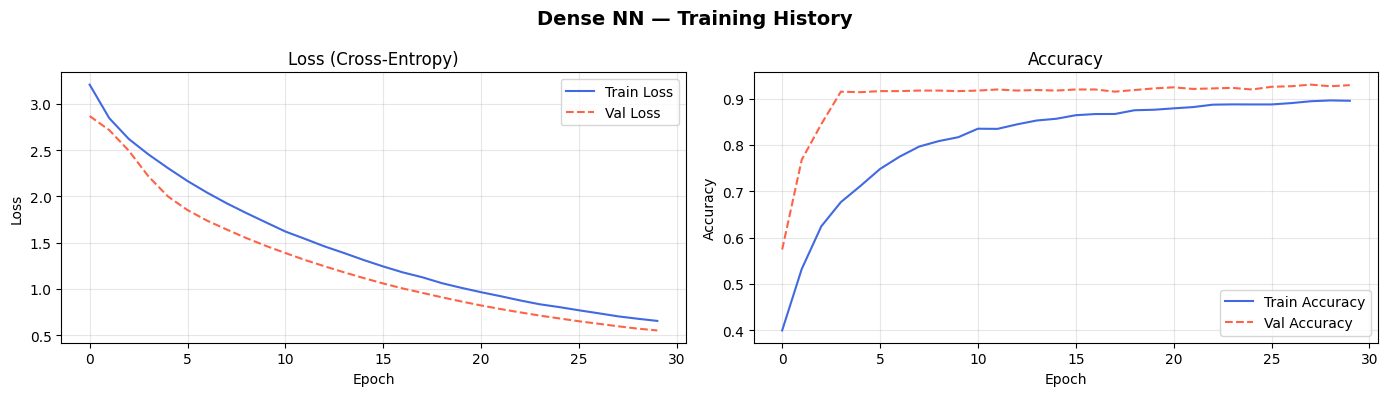

✅ History plot saved as history_dense_nn.png


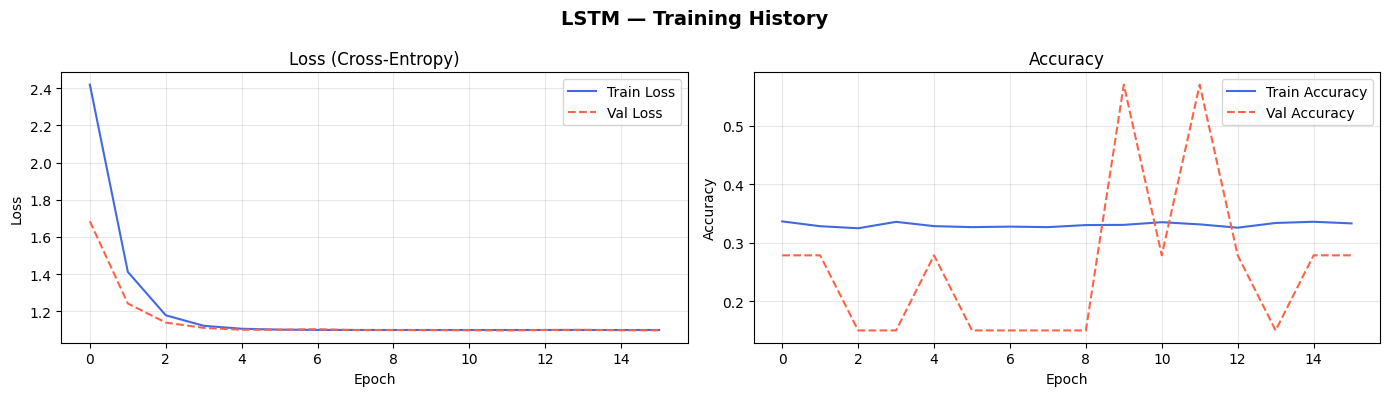

✅ History plot saved as history_lstm.png


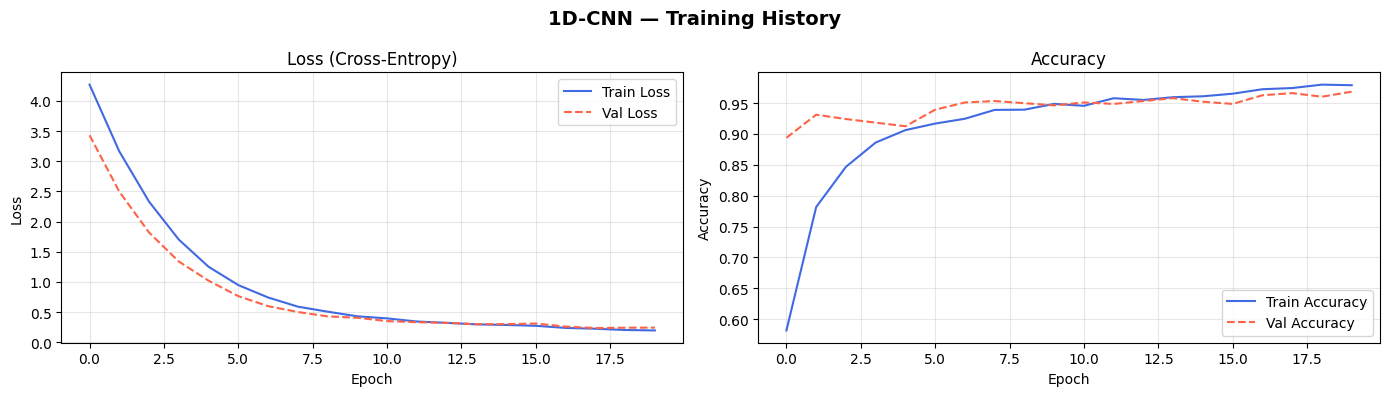

✅ History plot saved as history_1d-cnn.png


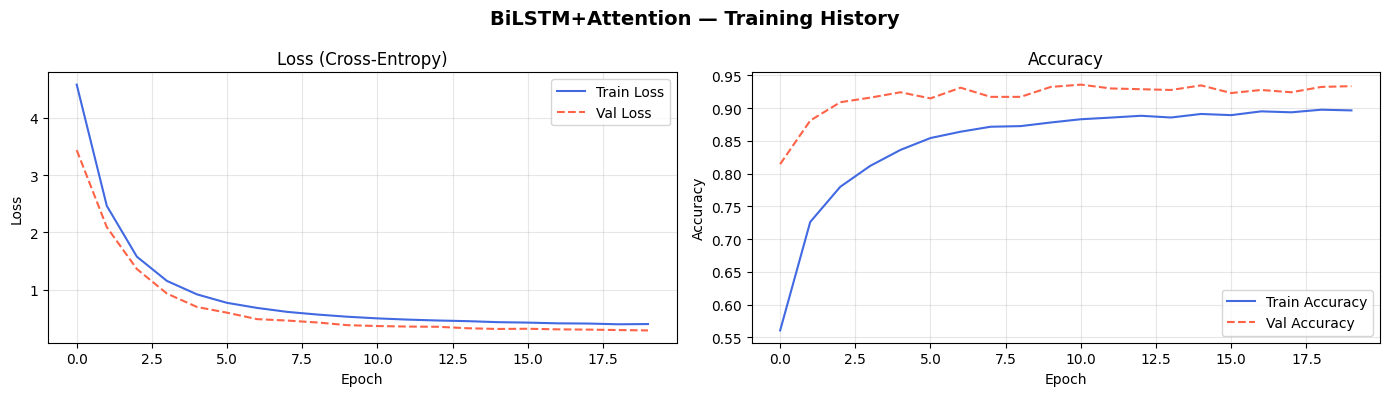

✅ History plot saved as history_bilstm+attention.png


In [26]:
# 9.1  Utility: plot training history
def plot_training_history(history, model_name):
    """Plot loss and accuracy curves for training and validation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss',     color='royalblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',       color='tomato', linestyle='--')
    axes[0].set_title('Loss (Cross-Entropy)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='royalblue')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f'history_{model_name.lower().replace(" ", "_")}.png'
    # plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ History plot saved as {fname}")


# Plot for all models
plot_training_history(history_dense,  'Dense NN')
plot_training_history(history_lstm,   'LSTM')
plot_training_history(history_cnn,    '1D-CNN')
plot_training_history(history_bilstm, 'BiLSTM+Attention')


In [27]:
# 9.2  Utility: evaluate a model and print report
label_names = ['Negative', 'Neutral', 'Positive']

def evaluate_model(model, X_test_pad, y_test, model_name):
    """
    Evaluate a trained model on the test set.
    Returns a dict of metrics and predicted labels.
    """
    y_pred_proba = model.predict(X_test_pad, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = np.array(y_test)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Set Results")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f} (macro)")
    print(f"  Recall    : {rec:.4f} (macro)")
    print(f"  F1-Score  : {f1:.4f} (macro)")
    print(f"{'='*55}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=label_names, zero_division=0))

    return {'name': model_name, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}


# Evaluate all models
results_dense  = evaluate_model(dense_model,  X_test_pad, y_test, 'Dense NN')
results_lstm   = evaluate_model(lstm_model,   X_test_pad, y_test, 'LSTM')
results_cnn    = evaluate_model(cnn_model,    X_test_pad, y_test, '1D-CNN')
results_bilstm = evaluate_model(bilstm_model, X_test_pad, y_test, 'BiLSTM+Attention')


  Dense NN — Test Set Results
  Accuracy  : 0.9366
  Precision : 0.9015 (macro)
  Recall    : 0.9265 (macro)
  F1-Score  : 0.9096 (macro)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.96      0.86       152
     Neutral       0.94      0.84      0.89       281
    Positive       0.99      0.98      0.98       576

    accuracy                           0.94      1009
   macro avg       0.90      0.93      0.91      1009
weighted avg       0.94      0.94      0.94      1009


  LSTM — Test Set Results
  Accuracy  : 0.5709
  Precision : 0.1903 (macro)
  Recall    : 0.3333 (macro)
  F1-Score  : 0.2423 (macro)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       152
     Neutral       0.00      0.00      0.00       281
    Positive       0.57      1.00      0.73       576

    accuracy                           0.57      1009
   macro avg       0.19  

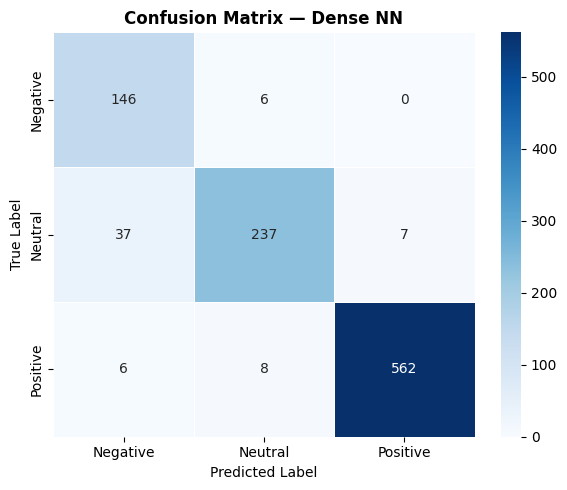

✅ Confusion matrix saved as cm_dense_nn.png


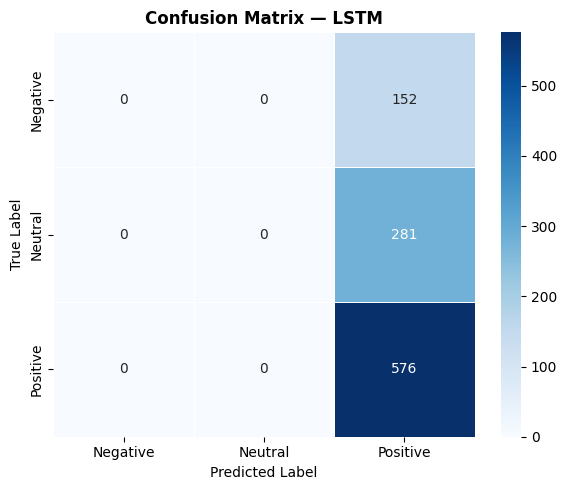

✅ Confusion matrix saved as cm_lstm.png


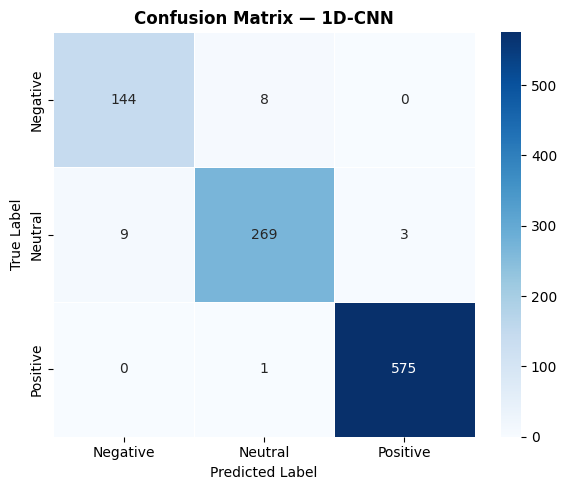

✅ Confusion matrix saved as cm_1d-cnn.png


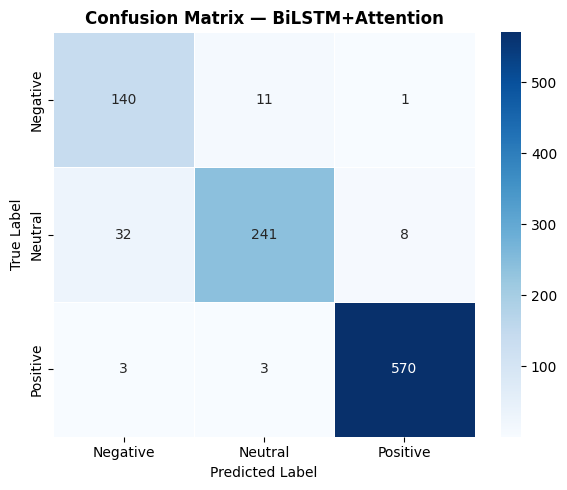

✅ Confusion matrix saved as cm_bilstmattention.png


In [28]:
# 9.3  Confusion Matrices
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Plot a heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5, linecolor='white')
    plt.title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fname = f'cm_{model_name.lower().replace(" ", "_").replace("+", "")}.png'
    # plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Confusion matrix saved as {fname}")

y_true = np.array(y_test)
plot_confusion_matrix(y_true, results_dense['y_pred'],  'Dense NN')
plot_confusion_matrix(y_true, results_lstm['y_pred'],   'LSTM')
plot_confusion_matrix(y_true, results_cnn['y_pred'],    '1D-CNN')
plot_confusion_matrix(y_true, results_bilstm['y_pred'], 'BiLSTM+Attention')



📊 Model Comparison Table:
                  Accuracy  Precision  Recall  F1-Score
Model                                                  
Dense NN            0.9366     0.9015  0.9265    0.9096
LSTM                0.5709     0.1903  0.3333    0.2423
1D-CNN              0.9792     0.9679  0.9676    0.9677
BiLSTM+Attention    0.9425     0.9099  0.9228    0.9142


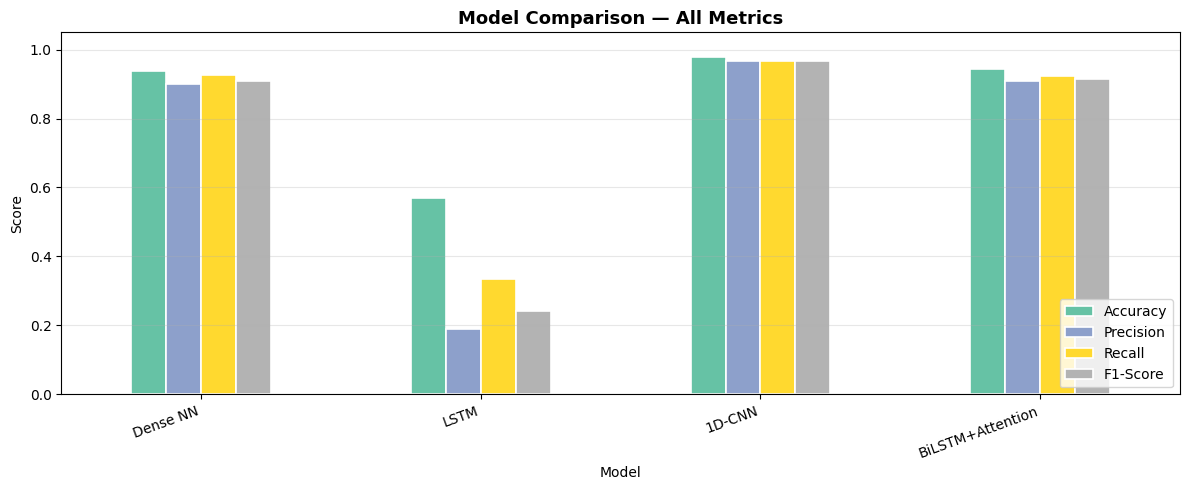

✅ Comparison chart saved.


In [29]:
# 9.4  Side-by-side model comparison table
all_results = [results_dense, results_lstm, results_cnn, results_bilstm]

comparison_df = pd.DataFrame([{
    'Model'    : r['name'],
    'Accuracy' : round(r['acc'],  4),
    'Precision': round(r['prec'], 4),
    'Recall'   : round(r['rec'],  4),
    'F1-Score' : round(r['f1'],   4),
} for r in all_results])

comparison_df = comparison_df.set_index('Model')
print("\n📊 Model Comparison Table:")
print(comparison_df.to_string())

# Bar chart comparison
comparison_df.plot(kind='bar', figsize=(12, 5), colormap='Set2',
                   edgecolor='white', linewidth=1.2)
plt.title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved.")


## ⚙️ Section 10: Model Optimization (Hyperparameter Tuning)

We manually grid-search over the most impactful hyperparameters for the **best-performing model** (BiLSTM+Attention):

| Hyperparameter | Values Tried |
|---------------|-------------|
| Learning rate | 5e-4, 1e-4 |
| Batch size    | 32, 64, 128 |
| Dropout rate  | 0.3, 0.4 |
| LSTM units    | 32, 64 |
| Embedding dim | 100 |

In [30]:
# 10.1  Manual grid search over key hyperparameters
import itertools

param_grid = {
    'lr'        : [5e-4, 1e-4], 
    'dropout'   : [0.3, 0.4],  
    'lstm_units': [32, 64], 
    'batch'     : [32, 64],
}

# Create all combinations
keys   = list(param_grid.keys())
values = list(param_grid.values())
combos = list(itertools.product(*values))

# Limit to 8 combinations (randomly sampled)
np.random.seed(SEED)
np.random.shuffle(combos)
combos = combos[:8]

print(f"Testing {len(combos)} hyperparameter combinations...\n")

best_f1     = 0.0
best_params = {}
tuning_log  = []

for combo in combos:
    params = dict(zip(keys, combo))
    print(f"Trying: {params}")

    # Build a compact BiLSTM for speed
    inp = Input(shape=(MAX_LEN,))
    emb = layers.Embedding(vocab_size, EMBED_DIM)(inp)
    x   = layers.SpatialDropout1D(params['dropout'])(emb)
    x   = layers.Bidirectional(
              layers.LSTM(params['lstm_units'], 
                          dropout=params['dropout'],
                          recurrent_dropout=params['dropout'],
                          kernel_regularizer=keras.regularizers.l2(0.01),
                          recurrent_regularizer=keras.regularizers.l2(0.01),
                          return_sequences=False))(x)
    x   = layers.Dense(32, activation='relu')(x)
    x   = layers.Dropout(params['dropout'])(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    m   = Model(inp, out)

    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params['lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    cb = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
    m.fit(
        X_train_pad, y_train_cat,
        validation_data=(X_val_pad, y_val_cat),
        epochs=20,
        batch_size=params['batch'],
        callbacks=cb,
        class_weight=class_weight_dict,
        verbose=0,
    )

    y_pred_t = np.argmax(m.predict(X_test_pad, verbose=0), axis=1)
    f1_val   = f1_score(np.array(y_test), y_pred_t, average='macro', zero_division=0)
    acc_val  = accuracy_score(np.array(y_test), y_pred_t)
    print(f"  → Val F1 = {f1_val:.4f} | Accuracy = {acc_val:.4f}\n")
    tuning_log.append({**params, 'f1': round(f1_val, 4), 'acc': round(acc_val, 4)})

    if f1_val > best_f1:
        best_f1     = f1_val
        best_params = params
    
    # Free GPU memory between runs
    del m, inp, emb, x, out
    import gc; gc.collect()

print('=' * 55)
print(f'Best Hyperparameters  : {best_params}')
print(f'Best Validation F1    : {best_f1:.4f}')
print('=' * 55)

tuning_df = pd.DataFrame(tuning_log).sort_values('f1', ascending=False)
print('Full tuning results (sorted by F1):')
print(tuning_df.to_string(index=False))

Testing 8 hyperparameter combinations...

Trying: {'lr': 0.0005, 'dropout': 0.3, 'lstm_units': 32, 'batch': 32}
  → Val F1 = 0.9770 | Accuracy = 0.9832

Trying: {'lr': 0.0005, 'dropout': 0.3, 'lstm_units': 32, 'batch': 64}
  → Val F1 = 0.9778 | Accuracy = 0.9832

Trying: {'lr': 0.0005, 'dropout': 0.4, 'lstm_units': 32, 'batch': 64}
  → Val F1 = 0.9803 | Accuracy = 0.9851

Trying: {'lr': 0.0001, 'dropout': 0.4, 'lstm_units': 64, 'batch': 32}
  → Val F1 = 0.9685 | Accuracy = 0.9762

Trying: {'lr': 0.0001, 'dropout': 0.4, 'lstm_units': 32, 'batch': 64}
  → Val F1 = 0.9132 | Accuracy = 0.9395

Trying: {'lr': 0.0001, 'dropout': 0.3, 'lstm_units': 64, 'batch': 64}
  → Val F1 = 0.9619 | Accuracy = 0.9722

Trying: {'lr': 0.0001, 'dropout': 0.3, 'lstm_units': 32, 'batch': 32}
  → Val F1 = 0.9620 | Accuracy = 0.9722

Trying: {'lr': 0.0001, 'dropout': 0.3, 'lstm_units': 32, 'batch': 64}
  → Val F1 = 0.9527 | Accuracy = 0.9653

Best Hyperparameters  : {'lr': 0.0005, 'dropout': 0.4, 'lstm_units': 3

## Section 11: Error Analysis

Examine which reviews the **best model (BiLSTM+Attention)** got wrong.  
Understanding misclassifications reveals dataset noise, model biases, or ambiguous reviews.

In [31]:
# 11.1  Collect misclassified samples
y_pred_best = results_bilstm['y_pred']
y_true_arr  = np.array(y_test)

# DataFrame of test examples with predictions
test_df = pd.DataFrame({
    'Review Text'    : X_test,
    'True Label'     : y_true_arr,
    'Predicted Label': y_pred_best,
    'True Name'      : [label_names[l] for l in y_true_arr],
    'Pred Name'      : [label_names[l] for l in y_pred_best],
})

mis_df = test_df[test_df['True Label'] != test_df['Predicted Label']].copy()
print(f"Total misclassified : {len(mis_df)} / {len(test_df)} ({len(mis_df)/len(test_df)*100:.1f}%)")
print(f"Correctly classified: {len(test_df)-len(mis_df)} / {len(test_df)} ({(1-len(mis_df)/len(test_df))*100:.1f}%)")


Total misclassified : 58 / 1009 (5.7%)
Correctly classified: 951 / 1009 (94.3%)



Misclassification breakdown:
True Name Pred Name  Count
  Neutral  Negative     32
 Negative   Neutral     11
  Neutral  Positive      8
 Positive  Negative      3
 Positive   Neutral      3
 Negative  Positive      1


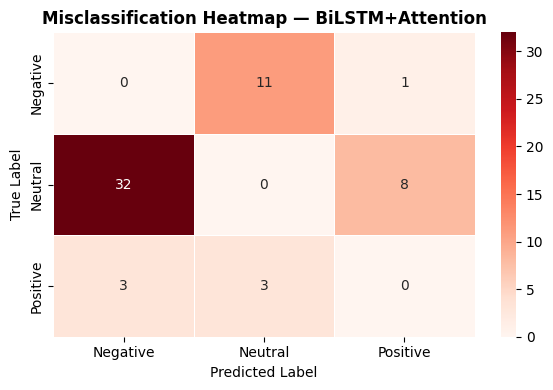

In [32]:
# 11.2  Error distribution by class pair
error_pairs = mis_df.groupby(['True Name', 'Pred Name']).size().reset_index(name='Count')
error_pairs = error_pairs.sort_values('Count', ascending=False)
print("\nMisclassification breakdown:")

if len(error_pairs) == 0:
    print("✅ No misclassifications found — the model achieved perfect accuracy on the test set!")
    print("   Skipping heatmap (no errors to visualise).")
else:
    print(error_pairs.to_string(index=False))

    # Heatmap of confusion pair counts
    pivot = error_pairs.pivot(index='True Name', columns='Pred Name', values='Count').fillna(0)
    plt.figure(figsize=(6, 4))
    sns.heatmap(pivot.astype(int), annot=True, fmt='d', cmap='Reds',
                linewidths=0.5, linecolor='white')
    plt.title('Misclassification Heatmap — BiLSTM+Attention', fontsize=12, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    # plt.savefig('error_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


In [33]:
# 11.3  Display sample misclassified reviews
print("\n=== SAMPLE MISCLASSIFIED REVIEWS ===")
for _, row in mis_df.sample(min(10, len(mis_df)), random_state=SEED).iterrows():
    print(f"\n  True: {row['True Name']:8s} | Predicted: {row['Pred Name']}")
    print(f"  Review: {row['Review Text'][:140]}")
    print("  " + "-"*70)



=== SAMPLE MISCLASSIFIED REVIEWS ===

  True: Neutral  | Predicted: Negative
  Review: picture quality good expected menu navigation confusing
  ----------------------------------------------------------------------

  True: Neutral  | Predicted: Negative
  Review: brightness disappointing android lag lot
  ----------------------------------------------------------------------

  True: Neutral  | Predicted: Negative
  Review: overall nice software update sometimes make slower
  ----------------------------------------------------------------------

  True: Neutral  | Predicted: Positive
  Review: thing good fantastic system freeze
  ----------------------------------------------------------------------

  True: Neutral  | Predicted: Negative
  Review: interface feel slow sometimes picture quality great
  ----------------------------------------------------------------------

  True: Positive | Predicted: Neutral
  Review: mixed feeling honestly interface look clean good watching movie

## Section 12: LIME Word-Importance Explainability

**LIME (Local Interpretable Model-Agnostic Explanations)** explains individual predictions by identifying which words most influenced the model's decision.


Review (idx=0)
  True: Negative | Predicted: Negative
  Text: speaker bass weak interface slow good gaming...


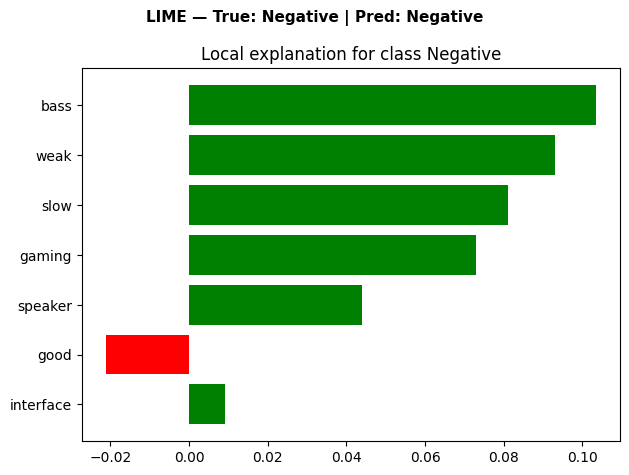


Review (idx=1)
  True: Neutral | Predicted: Neutral
  Text: gaming console mode work flawlessly minimal lag beautiful graphic display...


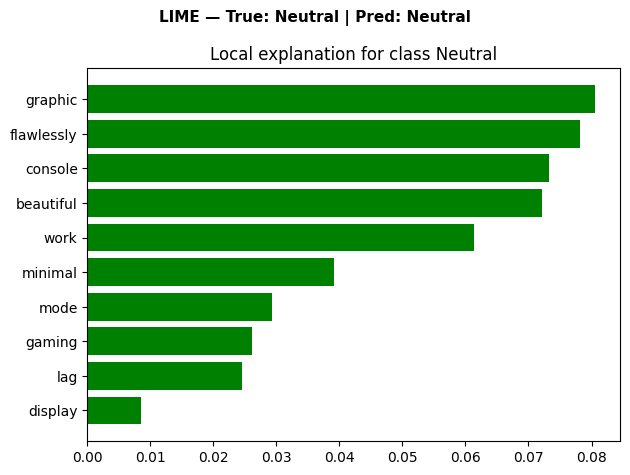


Review (idx=7)
  True: Positive | Predicted: Positive
  Text: build quality feel premium bezel less design make screen look even larger...


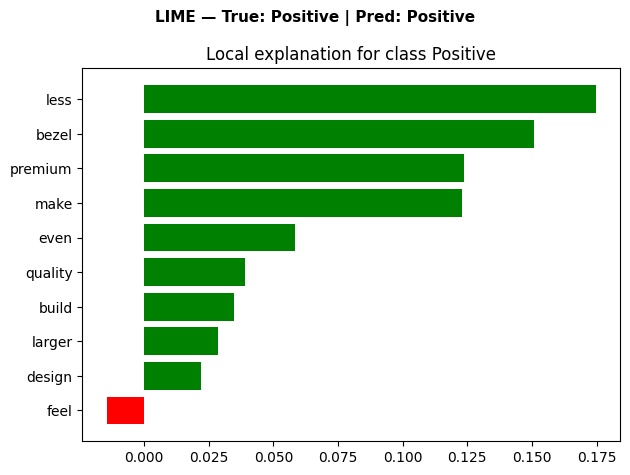

In [34]:
# 12.1  LIME prediction function + explanations
from lime.lime_text import LimeTextExplainer
def predict_proba_fn(texts):
    """Wrapper so LIME can call our BiLSTM model."""
    seqs = tokenizer.texts_to_sequences(texts)
    pads = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
    return bilstm_model.predict(pads, verbose=0)

explainer = LimeTextExplainer(class_names=label_names, random_state=SEED)

# Pick 3 diverse test samples
sample_indices = []
for target_class in [0, 1, 2]:
    idxs = np.where(y_true_arr == target_class)[0]
    if len(idxs) > 0:
        sample_indices.append(int(idxs[0]))

for idx in sample_indices:
    review_text = X_test[idx]
    true_label  = label_names[y_true_arr[idx]]
    pred_label  = label_names[y_pred_best[idx]]

    print(f"\n{'='*65}")
    print(f"Review (idx={idx})")
    print(f"  True: {true_label} | Predicted: {pred_label}")
    print(f"  Text: {review_text[:120]}...")

    exp = explainer.explain_instance(
        review_text, predict_proba_fn,
        num_features=10, num_samples=200,
        labels=[y_true_arr[idx]]
    )

    # # Save HTML explanation
    # html_path = f'lime_explanation_{true_label.lower()}.html'
    # exp.save_to_file(html_path)
    # print(f"  ✅ LIME explanation saved: {html_path}")

    # Plot inline
    fig = exp.as_pyplot_figure(label=y_true_arr[idx])
    fig.suptitle(f'LIME — True: {true_label} | Pred: {pred_label}',
                    fontsize=11, fontweight='bold')
    plt.tight_layout()
    # plt.savefig(f'lime_plot_{true_label.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


## Section 13 : Predict Sentiment for New Reviews

**Input a custom review text** and get predictions from all 4 trained models with confidence scores!

Simply modify the `new_review` variable below with your review text and run the cell.

In [35]:
# 13.1  Predict sentiment for a new review

new_review = """audio clear sufficiently loud average sized room bass could slightly better though overall good value price paid would recommend to anyone looking for budget headphones
"""

# 13.2  Preprocess the new review

new_review_clean = new_review.lower()
new_review_clean = re.sub(r'http\S+|www\S+', '', new_review_clean)  # Remove URLs
new_review_clean = re.sub(r'[^a-zA-Z\s]', '', new_review_clean)  # Remove special chars
new_review_clean = ' '.join(new_review_clean.split())  # Normalize whitespace

print("\n" + "="*70)
print("NEW REVIEW SENTIMENT PREDICTION")
print("="*70)
print(f"\nOriginal Review:\n  {new_review}\n")
print(f"Cleaned Review:\n  {new_review_clean}\n")

# Convert to sequence and pad
new_review_seq = tokenizer.texts_to_sequences([new_review_clean])
new_review_pad = pad_sequences(new_review_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# 13.3  Get predictions from all 4 models
label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}

print("\n" + "-"*70)
print("PREDICTIONS FROM ALL MODELS:")
print("-"*70)

# Model predictions
models = {
    'Dense NN': dense_model,
    'LSTM': lstm_model,
    '1D-CNN': cnn_model,
    'BiLSTM+Attention': bilstm_model,
}

predictions = {}

for model_name, model in models.items():
    probs = model.predict(new_review_pad, verbose=0)[0]
    pred_class = np.argmax(probs)
    pred_label = label_names[pred_class]
    confidence = probs[pred_class] * 100
    
    predictions[model_name] = {
        'class': pred_class,
        'label': pred_label,
        'confidence': confidence,
        'probs': probs
    }
    
    print(f"\n  {model_name:20s}:")
    print(f"    Prediction: {pred_label.upper():10s} (Confidence: {confidence:.2f}%)")
    print(f"    {'-'*50}")
    print(f"    Negative: {probs[0]*100:6.2f}% | Neutral: {probs[1]*100:6.2f}% | Positive: {probs[2]*100:6.2f}%")

# 13.4  Ensemble prediction (majority voting)
print("\n" + "-"*70)
print("ENSEMBLE PREDICTION (Majority Voting):")
print("-"*70)

pred_classes = [predictions[name]['class'] for name in models.keys()]
class_counts = Counter(pred_classes)
ensemble_class = class_counts.most_common(1)[0][0]
ensemble_label = label_names[ensemble_class]
consensus_pct = (class_counts[ensemble_class] / len(models)) * 100

print(f"\n  Ensemble Prediction: {ensemble_label.upper()}")
print(f"  Model Agreement: {class_counts[ensemble_class]}/{len(models)} ({consensus_pct:.0f}%)")
print(f"\n  Breakdown:")
for cls, name in label_names.items():
    count = class_counts.get(cls, 0)
    print(f"    {name.capitalize():10s}: {count} model(s)")

print("\n" + "="*70 + "\n")


NEW REVIEW SENTIMENT PREDICTION

Original Review:
  audio clear sufficiently loud average sized room bass could slightly better though overall good value price paid would recommend to anyone looking for budget headphones


Cleaned Review:
  audio clear sufficiently loud average sized room bass could slightly better though overall good value price paid would recommend to anyone looking for budget headphones


----------------------------------------------------------------------
PREDICTIONS FROM ALL MODELS:
----------------------------------------------------------------------

  Dense NN            :
    Prediction: NEUTRAL    (Confidence: 98.44%)
    --------------------------------------------------
    Negative:   1.12% | Neutral:  98.44% | Positive:   0.44%

  LSTM                :
    Prediction: POSITIVE   (Confidence: 33.47%)
    --------------------------------------------------
    Negative:  33.06% | Neutral:  33.47% | Positive:  33.47%

  1D-CNN              :
    Predictio

In [36]:
# Saving the preprocessed dataset with mapped sentiment labels

label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

# map numeric label → string and keep the columns we care about
df_raw['sentiment'] = df_raw['label'].map(label_map)

df_raw[['Review Text', 'clean_text', 'sentiment']].to_csv(
    'preprocessed_sonybravia_reviews.csv', index=False
)

print("✅ preprocessed dataset saved as 'preprocessed_sonybravia_reviews.csv'")
print(df_raw[['clean_text','sentiment']].head())

✅ preprocessed dataset saved as 'preprocessed_sonybravia_reviews.csv'
                                          clean_text sentiment
0  display brightness perfect even daylight issue...  positive
1       stand stable well built also easy wall mount  positive
2  color calibration box almost perfect minimal a...  positive
3  color reproduction accurate watching nature do...  positive
4  picture adjustment allow fine tuning personall...  positive
